## Now to implement the Negative Binomial regression

In [104]:
import clean
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import pandas as pd

In [105]:
sf_hazards, demographics, dictionary = clean.load_hazards_data(
    'calenviroscreen40resultsdatadictionary_F_2021.xlsx'
)
sf_hazards = clean.filter_san_francisco(sf_hazards)
print(f"SF census tracts: {len(sf_hazards)}")

SF census tracts: 195


In [106]:
sf_hazards, cleaned_covariates = clean.standardize(sf_hazards, clean.HAZARD_COVARIATES)

In [107]:
df = clean.prepare_analysis_data(
    ems_path='Fire_Department_and_Emergency_Medical_Services_Dispatched_Calls_for_Service.csv',
    hazards_path='calenviroscreen40resultsdatadictionary_F_2021.xlsx',
)

/Users/evie/Berkeley/STAT230A/project/health/clean.py:36: DtypeWarning: Columns (0: Box) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


Standardized columns: ['ozone_std', 'pm2.5_std', 'diesel_pm_std', 'drinking_water_std', 'lead_std', 'pesticides_std', 'tox._release_std', 'traffic_std', 'cleanup_sites_std', 'groundwater_threats_std', 'haz._waste_std', 'imp._water_bodies_std', 'solid_waste_std', 'asthma_std', 'low_birth_weight_std', 'cardiovascular_disease_std', 'education_std', 'linguistic_isolation_std', 'poverty_std', 'unemployment_std', 'housing_burden_std']


In [108]:
df.head()

,census_tract,total_population,california_county,zip,approximate_location,longitude,latitude,ces_4.0_score,ces_4.0_percentile,ces_4.0_percentile_range,...,imp._water_bodies_std,solid_waste_std,asthma_std,low_birth_weight_std,cardiovascular_disease_std,education_std,linguistic_isolation_std,poverty_std,unemployment_std,housing_burden_std
0,6075023200,3972,San Francisco,94124,San Francisco,-122.386139,37.727755,54.605674,92.208775,90-95%,...,1.012849,6.286587,3.191068,1.946149,2.018325,1.306247,-0.097772,0.459864,0.761136,3.238608
1,6075023103,2890,San Francisco,94124,San Francisco,-122.375965,37.735632,50.508864,88.401412,85-90%,...,1.542051,4.083312,3.191068,1.731002,2.018325,0.891870,-0.644297,3.829840,0.880762,1.014756
2,6075023001,5398,San Francisco,94124,San Francisco,-122.401760,37.735192,49.329481,87.191125,85-90%,...,0.836449,1.461898,3.191068,0.913445,2.018325,1.518255,0.772963,0.717926,0.242757,1.513988
3,6075023400,3661,San Francisco,94124,San Francisco,-122.390088,37.721593,46.984298,84.404942,80-85%,...,1.012849,5.048250,3.191068,0.839680,2.018325,1.730262,1.078647,1.431389,0.840887,-0.785505
4,6075023102,4549,San Francisco,94124,San Francisco,-122.384498,37.734492,46.932707,84.329299,80-85%,...,1.542051,2.603741,3.191068,2.321119,2.018325,0.583496,-0.551666,2.038592,2.954277,1.498860


## In first iteration just evaluate one on column of average calls/week

In [109]:
std_covariates = []
for cov in clean.HAZARD_COVARIATES: 
    std_covariates.append(f'{cov}_std')

X = sm.add_constant(df[std_covariates])
y = df['call_avg_aug_oct']

model = sm.NegativeBinomial(y, X).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 3.402268
         Iterations: 26
         Function evaluations: 38
         Gradient evaluations: 38
                     NegativeBinomial Regression Results                      
Dep. Variable:       call_avg_aug_oct   No. Observations:                  182
Model:               NegativeBinomial   Df Residuals:                      160
Method:                           MLE   Df Model:                           21
Date:                Tue, 12 May 2026   Pseudo R-squ.:                  0.1784
Time:                        22:51:14   Log-Likelihood:                -619.21
converged:                       True   LL-Null:                       -753.68
Covariance Type:            nonrobust   LLR p-value:                 6.325e-45
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const 

Pseudo R^2 of 0.175, the covariates included explain about 17.5% of the variance in call volume. LLR p-value assess the overall significance of the model compared to the null model (low p value; below 0.05 so indicates the model is statistically significant!). 

On first evaluation, poverty is the strongest predictor. (an intuitive result; aligns with literature...see if want to reference literature)

hazardous waste second strongest pollution signals, followed by cleanup signts, low birth rate (a health outcome predictor and maybe a proxy for chronic community health burden), and housing burden (larger percentage of low income households --> incr in calls). 

Some counterintuitive results: groundwater threats, ozone, impaired water bodies, pesticides, and *unemployment. Strage that unemployment is negatively associated with call volume with poverty is positively associated with call volume. May need to evaluate for collinearity in covariates. 

## Evaluate collinearity of covariates

                level_0                   level_1        0
0             ozone_std                 ozone_std      NaN
1             ozone_std                 pm2.5_std      NaN
2             ozone_std             diesel_pm_std      NaN
3             ozone_std        drinking_water_std      NaN
4             ozone_std                  lead_std      NaN
..                  ...                       ...      ...
436  housing_burden_std             education_std      NaN
437  housing_burden_std  linguistic_isolation_std      NaN
438  housing_burden_std               poverty_std  0.62063
439  housing_burden_std          unemployment_std      NaN
440  housing_burden_std        housing_burden_std      NaN

[441 rows x 3 columns]


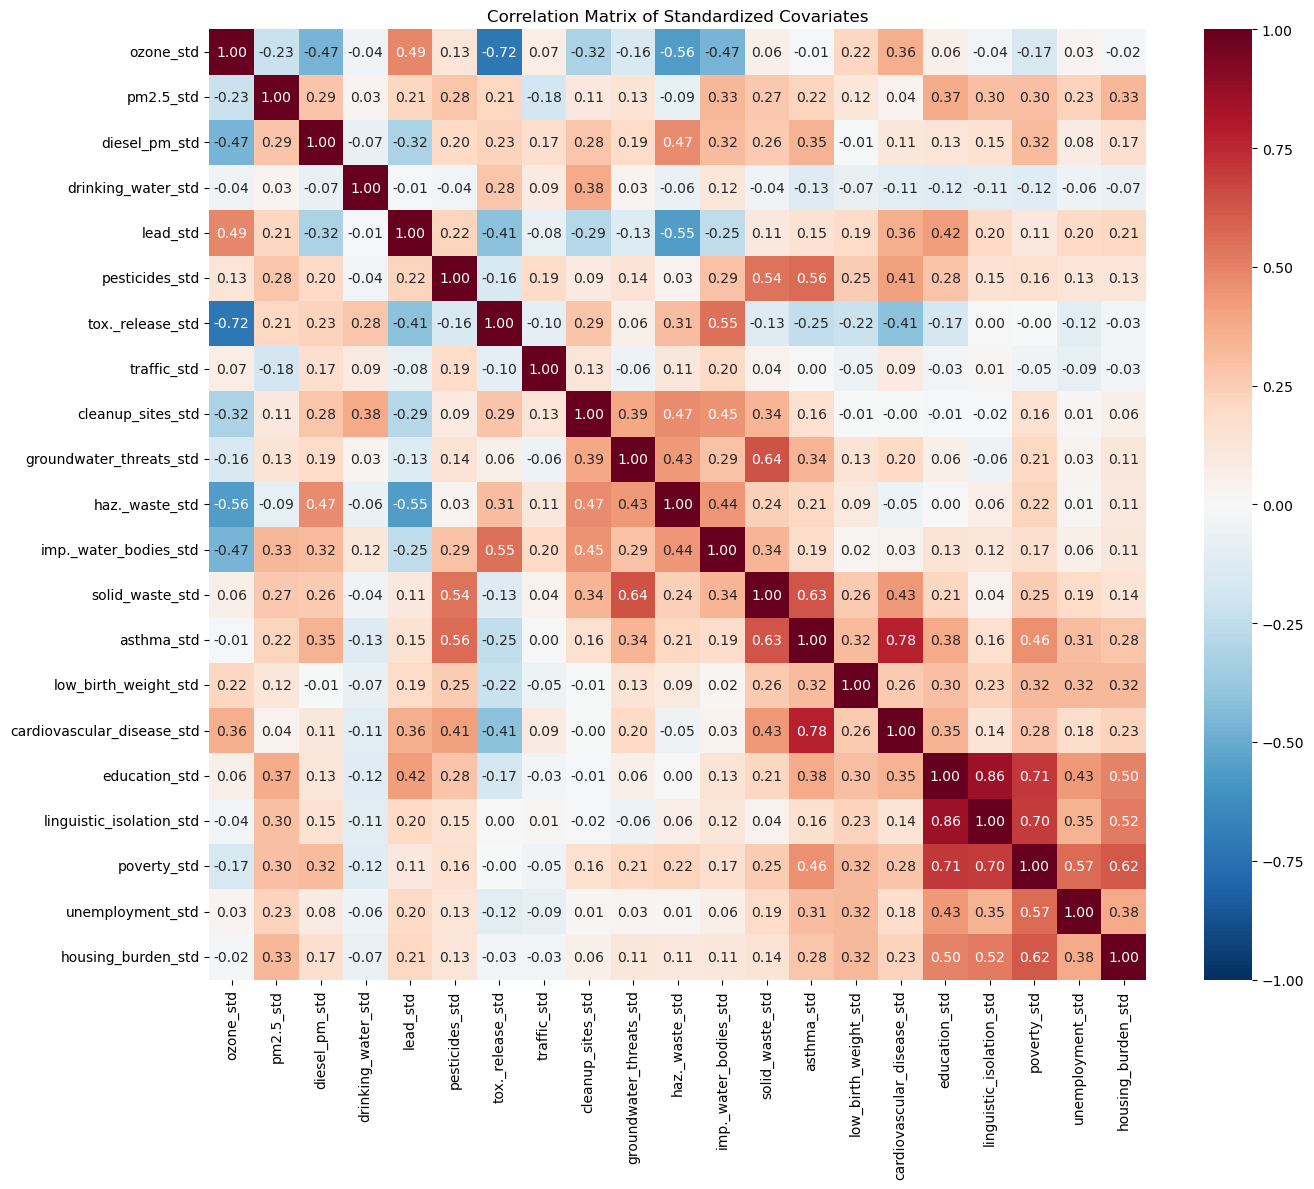

In [110]:
corr = df[std_covariates].corr()

# Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1)
plt.title('Correlation Matrix of Standardized Covariates')
plt.tight_layout()

# Flag high correlations explicitly
high_corr = (corr.abs() > 0.6) & (corr != 1.0)
print(corr[high_corr].stack().reset_index())

Just on a first pass evaluation, there is are many correlated features. (to name a few): High correlation of poverty with education and linguistic isolation (and subsequently education with linguistic isolation). Asthma and cardiovascular disease. 



## VIF evaluation 

In [111]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame({
    'variable': std_covariates,
    'VIF': [variance_inflation_factor(X.values, i) 
            for i in range(1, X.shape[1])]   # skip constant
}).sort_values('VIF', ascending=False)

print(vif_df)
# Variables with VIF > 5 are candidates for removal or combination

                      variable       VIF
13                  asthma_std  8.910678
16               education_std  7.854913
17    linguistic_isolation_std  6.676046
0                    ozone_std  5.819239
15  cardiovascular_disease_std  5.632499
18                 poverty_std  4.514047
6             tox._release_std  4.381829
12             solid_waste_std  4.033062
10              haz._waste_std  3.416926
11       imp._water_bodies_std  3.042394
4                     lead_std  2.825819
9      groundwater_threats_std  2.536396
5               pesticides_std  2.291465
1                    pm2.5_std  2.157971
2                diesel_pm_std  2.034795
8            cleanup_sites_std  2.021833
20          housing_burden_std  1.912859
19            unemployment_std  1.702349
3           drinking_water_std  1.569534
7                  traffic_std  1.496609
14        low_birth_weight_std  1.462030


Will perform elastic net on this negative binomial regression. To avoid potential overfitting and deal with correlated features. OR should i use PCA to transform these correlated variables.... PCA would help with collinearity, but would lost interpretability of specific individual pollutant coefficients. Will go with elastic net. 

In [112]:
model = sm.GLM(y, X, family=sm.families.NegativeBinomial())

result = model.fit_regularized(
    method='elastic_net', 
    alpha=0.1, 
    L1_wt=0.5
)

print(result.params)


const                         2.699933
ozone_std                    -0.162239
pm2.5_std                     0.000000
diesel_pm_std                 0.076515
drinking_water_std            0.000000
lead_std                     -0.012221
pesticides_std               -0.046795
tox._release_std              0.000000
traffic_std                   0.000000
cleanup_sites_std             0.069913
groundwater_threats_std      -0.059640
haz._waste_std                0.229319
imp._water_bodies_std        -0.063384
solid_waste_std               0.000000
asthma_std                    0.149601
low_birth_weight_std          0.031260
cardiovascular_disease_std    0.000000
education_std                 0.000000
linguistic_isolation_std      0.000000
poverty_std                   0.195289
unemployment_std              0.000000
housing_burden_std            0.049320
dtype: float64


/Users/evie/miniconda3/envs/proj_230/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


## Write a reusable fxn

In [113]:
def nb_en(alpha=0.1, L1_wt=0.5): 
    X = sm.add_constant(df[std_covariates])
    y = df['call_avg_aug_oct']

    model = sm.GLM(y, X, family=sm.families.NegativeBinomial())

    result = model.fit_regularized(
        method='elastic_net', 
        alpha=0.1, 
        L1_wt=0.5
    )

    print(result.params)
    return result

### There is no summary function for the GLM model

In [114]:
def r_squared(result, y, X): 
    llf = model.loglike(result.params)
    
    null_model = sm.GLM(y, np.ones_like(X), family=sm.families.NegativeBinomial()).fit()
    llnull = null_model.llf

    pseudo_r2 = 1-(llf / llnull)
    return pseudo_r2

In [115]:
pseudo_r2 = r_squared(result, y, X)
print(f'Pseudo R2: {pseudo_r2}')

Pseudo R2: 0.05963036367448715


/Users/evie/miniconda3/envs/proj_230/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


Worse than initial R^2, buuut R^2 can be overly optimistic to model fitting!
Now really should do cross validation to evaluate for the best parameters

In [116]:
X = df[std_covariates].values
y = df['call_avg_aug_oct'].values
X = sm.add_constant(X)

# potential hyperparams to loop through
alphas = [0.01, 0.1, 1.0]
l1_weights = [0.2, 0.5, 0.8]

kf = KFold(n_splits=5, shuffle=True, random_state=42) # set for reproducibility

results = []

for a in alphas: 
    for lw in l1_weights: 
        fold_errors = []

        for train_idx, test_idx in kf.split(X): 
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            model = sm.GLM(y_train, X_train, family=sm.families.NegativeBinomial())
            try: 
                res = model.fit_regularized(method='elastic_net', alpha=a, L1_wt=lw)

                preds = res.predict(X_test)
                err = mean_absolute_error(y_test, preds)
                fold_errors.append(err)
            except: 
                continue

        results.append({
            'alpha': a, 
            'l1 ratio': lw,
            'mean_mae': np.mean(fold_errors)
        })

results_df = pd.DataFrame(results).sort_values('mean_mae')
print(results_df.head())

/Users/evie/miniconda3/envs/proj_230/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/Users/evie/miniconda3/envs/proj_230/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1464: UserWarning: Elastic net fitting did not converge
  warnings.warn("Elastic net fitting did not converge")
/Users/evie/miniconda3/envs/proj_230/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/Users/evie/miniconda3/envs/proj_230/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1464: UserWarning: Elastic net fitting did not converge
  warnings.warn("Elastic net fitting did not converg

   alpha  l1 ratio   mean_mae
0   0.01       0.2  10.097624
1   0.01       0.5  10.158427
3   0.10       0.2  10.207079
2   0.01       0.8  10.296773
4   0.10       0.5  10.758689


In [117]:
result_lowest_mean_mae = nb_en(0.01, 0.2)

/Users/evie/miniconda3/envs/proj_230/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


const                         2.699933
ozone_std                    -0.162239
pm2.5_std                     0.000000
diesel_pm_std                 0.076515
drinking_water_std            0.000000
lead_std                     -0.012221
pesticides_std               -0.046795
tox._release_std              0.000000
traffic_std                   0.000000
cleanup_sites_std             0.069913
groundwater_threats_std      -0.059640
haz._waste_std                0.229319
imp._water_bodies_std        -0.063384
solid_waste_std               0.000000
asthma_std                    0.149601
low_birth_weight_std          0.031260
cardiovascular_disease_std    0.000000
education_std                 0.000000
linguistic_isolation_std      0.000000
poverty_std                   0.195289
unemployment_std              0.000000
housing_burden_std            0.049320
dtype: float64


In [118]:
r_squared_lowest_mean_mae = r_squared(result_lowest_mean_mae, y, X)
print(f"R^2: {r_squared_lowest_mean_mae}")

R^2: 0.24753048145262524


/Users/evie/miniconda3/envs/proj_230/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


## Reduced Model
NB with just the most remaining variables: 

In [119]:
non_zero_mask = result_lowest_mean_mae.params != 0
selected_features = result_lowest_mean_mae.params[non_zero_mask].index.tolist()

selected_features.remove('const')

print(selected_features)

['ozone_std', 'diesel_pm_std', 'lead_std', 'pesticides_std', 'cleanup_sites_std', 'groundwater_threats_std', 'haz._waste_std', 'imp._water_bodies_std', 'asthma_std', 'low_birth_weight_std', 'poverty_std', 'housing_burden_std']


In [120]:
X = sm.add_constant(df[selected_features])
y = df['call_avg_aug_oct']

model = sm.NegativeBinomial(y, X).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 3.433327
         Iterations: 15
         Function evaluations: 27
         Gradient evaluations: 27
                     NegativeBinomial Regression Results                      
Dep. Variable:       call_avg_aug_oct   No. Observations:                  182
Model:               NegativeBinomial   Df Residuals:                      169
Method:                           MLE   Df Model:                           12
Date:                Tue, 12 May 2026   Pseudo R-squ.:                  0.1709
Time:                        22:51:17   Log-Likelihood:                -624.87
converged:                       True   LL-Null:                       -753.68
Covariance Type:            nonrobust   LLR p-value:                 3.504e-48
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const       

## Evaluating stability across seasons 

In [121]:
# df['call_avg_aug_oct']   -> summer/fall window
# df['call_avg_nov_jan']   -> fall/winter window

seasons = {
    'Aug-Oct': 'call_avg_aug_oct',
    'Nov-Jan': 'call_avg_nov_jan', 
    'Feb-Apr': 'call_avg_feb_apr', 
    'May-Jul': 'call_avg_may_jul'
}

X = sm.add_constant(df[selected_features])  
models = {}
results = {}

for season, outcome in seasons.items():
    y = df[outcome]
    model = sm.NegativeBinomial(y, X).fit(
        cov_type='cluster',
        cov_kwds={'groups': df['census_tract']}
    )
    models[season] = model
    results[season] = model.params
    print(f"\n{'='*50}")
    print(f"Season: {season}")
    print(model.summary())


Optimization terminated successfully.
         Current function value: 3.433327
         Iterations: 15
         Function evaluations: 27
         Gradient evaluations: 27

Season: Aug-Oct
                     NegativeBinomial Regression Results                      
Dep. Variable:       call_avg_aug_oct   No. Observations:                  182
Model:               NegativeBinomial   Df Residuals:                      169
Method:                           MLE   Df Model:                           12
Date:                Tue, 12 May 2026   Pseudo R-squ.:                  0.1709
Time:                        22:51:17   Log-Likelihood:                -624.87
converged:                       True   LL-Null:                       -753.68
Covariance Type:              cluster   LLR p-value:                 3.504e-48
                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [122]:
compare_df = pd.DataFrame({
    'variable':   selected_features,
    'coef_aug_oct': results['Aug-Oct'][1:-1].values,   # skip constant and alpha
    'coef_nov_jan': results['Nov-Jan'][1:-1].values,
    'coef_feb_apr': results['Feb-Apr'][1:-1].values, 
    'coef_may_jul': results['May-Jul'][1:-1].values
})

# Absolute and relative difference
compare_df['abs_diff']  = compare_df['coef_nov_jan'] - compare_df['coef_aug_oct']
compare_df['sign_flip'] = (
    np.sign(compare_df['coef_aug_oct']) != np.sign(compare_df['coef_nov_jan'])
)
compare_df['stable'] = (
    (~compare_df['sign_flip']) & 
    (compare_df['abs_diff'].abs() < 0.05)   # threshold: adjust to taste
)

print("\nCoefficient comparison across seasons:")
print(compare_df.round(4))

print("\nStable coefficients (same sign, small difference):")
print(compare_df[compare_df['stable']]['variable'].tolist())

print("\nSign flips across seasons (most interesting):")
print(compare_df[compare_df['sign_flip']])


Coefficient comparison across seasons:
                   variable  coef_aug_oct  coef_nov_jan  coef_feb_apr  \
0                 ozone_std       -0.2161       -0.1665       -0.2155   
1             diesel_pm_std        0.0879        0.0838        0.0995   
2                  lead_std       -0.0444       -0.0696       -0.0038   
3            pesticides_std       -0.1168       -0.1186       -0.1425   
4         cleanup_sites_std        0.1448        0.1220        0.1382   
5   groundwater_threats_std       -0.1933       -0.2087       -0.1976   
6            haz._waste_std        0.2371        0.2537        0.2542   
7     imp._water_bodies_std       -0.1622       -0.1634       -0.1568   
8                asthma_std        0.2619        0.2782        0.2531   
9      low_birth_weight_std        0.0844        0.0655        0.0682   
10              poverty_std        0.1581        0.1595        0.1460   
11       housing_burden_std        0.0910        0.0951        0.1146   

    coef_m

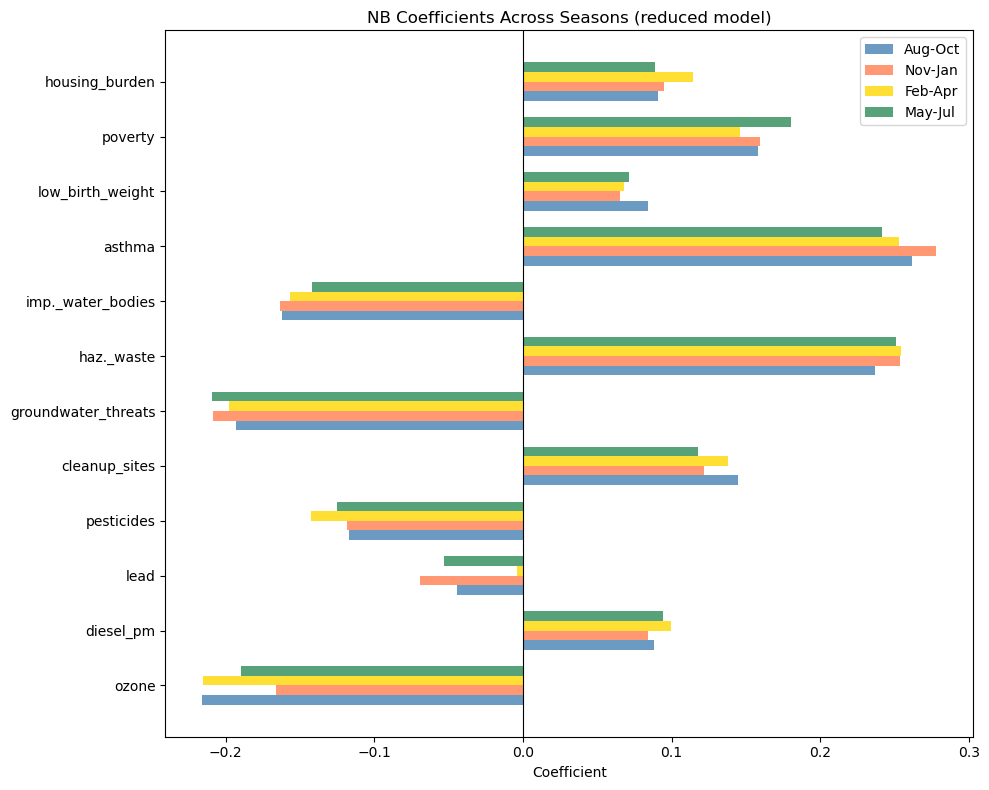

Aug-Oct   pseudo-R2: 0.1709
Nov-Jan   pseudo-R2: 0.1641
Feb-Apr   pseudo-R2: 0.1679
May-Jul   pseudo-R2: 0.1610


In [123]:
fig, ax = plt.subplots(figsize=(10, 8))

y_pos = np.arange(len(selected_features))
n_seasons = 4
width = 0.7 / n_seasons

colors = {'Aug-Oct': 'steelblue', 'Nov-Jan': 'coral', 'Feb-Apr': 'gold', 'May-Jul': 'seagreen'}

for i, (season, outcome) in enumerate(seasons.items()):
    col = f'coef_{season.lower().replace("-", "_")}'
    ax.barh(y_pos + (i - (n_seasons - 1) / 2) * width,
            compare_df[col], width, label=season,
            color=colors[season], alpha=0.8)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels([v.replace('_std', '') for v in selected_features])
ax.set_xlabel('Coefficient')
ax.set_title('NB Coefficients Across Seasons (reduced model)')
ax.legend()
plt.tight_layout()
plt.show()



for season in seasons:
    print(f"{season:8s}  pseudo-R2: {models[season].prsquared:.4f}")

Stability evaluation, why did the coeff for lead drop so drastically for Feb-Apr...